# 🏠 **Ames Housing Market Analysis: A Professional Deep Dive**

**Author:** Amit Pandey (as Technical Mentor)
**Date:** June 7, 2025
**Project Sprint Completion:** Sprints I, II, & III

---

### **Project Overview**

This notebook serves as a comprehensive guide for the Ames Housing Sprint Project, covering all tasks from initial business understanding through to in-depth exploratory data analysis (EDA). The goal is to provide a business with actionable insights into the Ames, Iowa real estate market. We will proceed methodically through the established sprint timeline, ensuring each step is deliberate, well-documented, and builds towards a cohesive final analysis.

**Audience:** Business executives and decision-makers.
**Product:** A detailed analytical report featuring:
1.  Clear and concise business questions relevant to the real estate domain.
2.  A transparent and robust data understanding and preprocessing methodology.
3.  Evidence-based answers to the business questions, supported by insightful data visualizations and statistical analysis.

## **Session I: Business & Data Foundation**

**Objective:** To establish the project's scope by understanding the business domain, framing initial analytical questions, and performing a preliminary inspection of the dataset.

### **1.1. Environment Setup: Importing Libraries**

Our first step is to import the essential Python libraries for our analysis. We will use `pandas` and `numpy` for data wrangling and numerical computation, and `matplotlib` with `seaborn` for powerful and aesthetic data visualization.

In [2]:
# Core libraries for data manipulation and analysis
import pandas as pd
import numpy as np

# Libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# --- Professional Visualization Settings ---
# Set a visually appealing style for all plots
sns.set_style('whitegrid')
plt.style.use('seaborn-v0_8-talk')

# Improve plot aesthetics and readability
plt.rcParams['figure.titleweight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['font.size'] = 12
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12

# Suppress ignorable warnings
warnings.filterwarnings('ignore')

# Configure pandas for better display
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

print("✅ Libraries imported and environment configured successfully.")

✅ Libraries imported and environment configured successfully.


### **1.2. Data Loading and Consolidation**

The project data is provided in two separate files: `Ames_Housing_North.csv` and `Ames_Housing_South.csv`. As per the initial project task, we must load both files and merge them into a single, unified DataFrame. This consolidated dataset will be the foundation for all subsequent analysis.

In [3]:
try:
    # Load the two datasets from the source files
    df_north = pd.read_csv('Ames_Housing_North.csv')
    df_south = pd.read_csv('Ames_Housing_South.csv')
    
    print("--- Dataset Loading ---")
    print(f"Shape of North dataset: {df_north.shape}")
    print(f"Shape of South dataset: {df_south.shape}")

    # Vertically concatenate the two dataframes to create a single master dataset
    # ignore_index=True is crucial to reset the index for the new combined dataframe
    df = pd.concat([df_north, df_south], ignore_index=True)

    print(f"\n--- Data Consolidation ---")
    print(f"Shape of the merged dataset: {df.shape}")
    print("Datasets successfully merged.")

except FileNotFoundError as e:
    print(f"Error: {e}. Please ensure both 'Ames_Housing_North.csv' and 'Ames_Housing_South.csv' are in the correct directory.")
    # Create an empty dataframe to prevent downstream errors in the notebook
    df = pd.DataFrame()

--- Dataset Loading ---
Shape of North dataset: (2107, 81)
Shape of South dataset: (380, 81)

--- Data Consolidation ---
Shape of the merged dataset: (2487, 81)
Datasets successfully merged.


### **1.3. Initial Data Reconnaissance**

With the data loaded, we perform a high-level inspection. This step, known as data understanding, is critical for forming a mental model of the dataset's structure, content, and potential quality issues.

In [6]:
if not df.empty:
    print("--- First 5 Rows of the Merged Dataset ---")
    display(df.head())

    print("\n--- DataFrame Structure and Data Types ---")
    # .info() provides a concise summary: index dtype, columns, non-null values, and memory usage.
    df.info()

    print("\n--- Descriptive Statistics for Numerical Columns ---")
    # .describe() generates summary statistics for numerical columns, revealing central tendency, dispersion, and shape.
    display(df.describe().T) # Transposing for better readability

--- First 5 Rows of the Merged Dataset ---


,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Heating,Heating QC,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,527105010,60,RL,74.000,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.000,TA,TA,PConc,Gd,TA,No,GLQ,791.000,Unf,0.000,137.000,928.000,GasA,Gd,Y,SBrkr,928,701,0,1629,0.000,0.000,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.000,Fin,2.000,482.000,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900
1,527105030,60,RL,78.000,9978,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,6,1998,1998,Gable,CompShg,VinylSd,VinylSd,BrkFace,20.000,TA,TA,PConc,TA,TA,No,GLQ,602.000,Unf,0.000,324.000,926.000,GasA,Ex,Y,SBrkr,926,678,0,1604,0.000,0.000,2,1,3,1,Gd,7,Typ,1,Gd,Attchd,1998.000,Fin,2.000,470.000,TA,TA,Y,360,36,0,0,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal,195500
2,527127150,120,RL,41.000,4920,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,StoneBr,Norm,Norm,TwnhsE,1Story,8,5,2001,2001,Gable,CompShg,CemntBd,CmentBd,NaN,0.000,Gd,TA,PConc,Gd,TA,Mn,GLQ,616.000,Unf,0.000,722.000,1338.000,GasA,Ex,Y,SBrkr,1338,0,0,1338,1.000,0.000,2,0,2,1,Gd,6,Typ,0,NaN,Attchd,2001.000,Fin,2.000,582.000,TA,TA,Y,0,0,170,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,213500
3,527145080,120,RL,43.000,5005,Pave,NaN,IR1,HLS,AllPub,Inside,Gtl,StoneBr,Norm,Norm,TwnhsE,1Story,8,5,1992,1992,Gable,CompShg,HdBoard,HdBoard,NaN,0.000,Gd,TA,PConc,Gd,TA,No,ALQ,263.000,Unf,0.000,1017.000,1280.000,GasA,Ex,Y,SBrkr,1280,0,0,1280,0.000,0.000,2,0,2,1,Gd,5,Typ,0,NaN,Attchd,1992.000,RFn,2.000,506.000,TA,TA,Y,0,82,0,0,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal,191500
4,527146030,120,RL,39.000,5389,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,StoneBr,Norm,Norm,TwnhsE,1Story,8,5,1995,1996,Gable,CompShg,CemntBd,CmentBd,NaN,0.000,Gd,TA,PConc,Gd,TA,No,GLQ,1180.000,Unf,0.000,415.000,1595.000,GasA,Ex,Y,SBrkr,1616,0,0,1616,1.000,0.000,2,0,2,1,Gd,5,Typ,1,TA,Attchd,1995.000,RFn,2.000,608.000,TA,TA,Y,237,152,0,0,0,0,NaN,NaN,NaN,0,3,2010,WD,Normal,236500



--- DataFrame Structure and Data Types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2487 entries, 0 to 2486
Data columns (total 81 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PID              2487 non-null   int64  
 1   MS SubClass      2487 non-null   int64  
 2   MS Zoning        2487 non-null   object 
 3   Lot Frontage     2065 non-null   float64
 4   Lot Area         2487 non-null   int64  
 5   Street           2487 non-null   object 
 6   Alley            195 non-null    object 
 7   Lot Shape        2487 non-null   object 
 8   Land Contour     2487 non-null   object 
 9   Utilities        2487 non-null   object 
 10  Lot Config       2487 non-null   object 
 11  Land Slope       2487 non-null   object 
 12  Neighborhood     2487 non-null   object 
 13  Condition 1      2487 non-null   object 
 14  Condition 2      2487 non-null   object 
 15  Bldg Type        2487 non-null   object 
 16  House Style     

,count,mean,std,min,25%,50%,75%,max
PID,2487.000,746638180.045,187392599.099,527105010.000,528431115.000,903204095.000,907275115.000,1007100110.000
MS SubClass,2487.000,60.800,43.607,20.000,20.000,60.000,70.000,190.000
Lot Frontage,2065.000,68.138,23.816,21.000,55.000,65.000,80.000,313.000
Lot Area,2487.000,10167.199,8443.945,1300.000,7200.000,9382.000,11691.000,215245.000
Overall Qual,2487.000,6.230,1.455,1.000,5.000,6.000,7.000,10.000
Overall Cond,2487.000,5.519,1.110,1.000,5.000,5.000,6.000,9.000
Year Built,2487.000,1973.401,32.168,1872.000,1951.000,1979.000,2003.000,2010.000
Year Remod/Add,2487.000,1986.692,20.394,1950.000,1971.000,1996.000,2004.000,2010.000
Mas Vnr Area,2464.000,103.632,183.443,0.000,0.000,0.000,166.000,1600.000
BsmtFin SF 1,2486.000,435.205,472.195,0.000,0.000,331.000,739.000,5644.000


### **1.4. Framing Business Questions ❓**

Based on the initial data exploration and the project's goal of understanding the real estate domain, we will frame a set of analytical questions. These questions are designed to be specific, measurable, and answerable with the data. They will guide our EDA in Session III.

1.  **Price & Value Drivers:** What are the primary determinants of house prices in Ames? Specifically, how do physical attributes like size (`Gr Liv Area`), overall quality (`Overall Qual`), and age impact the final `SalePrice`?
2.  **Neighborhood Analysis:** Which neighborhoods command the highest and lowest property values? Is there a significant price variance *within* the top-tier neighborhoods?
3.  **Impact of Amenities:** What is the quantifiable impact of key amenities like fireplaces, garages, and swimming pools on a property's sale price?
4.  **Temporal & Market Trends:** How have sale prices evolved over the years covered in the dataset? Are there specific months or seasons that exhibit higher sales activity or prices?
5.  **Condition vs. Price:** How significantly does the overall condition (`Overall Cond`) of a house affect its value, especially when compared to its quality (`Overall Qual`)?

## **Session II: Data Cleansing and Preparation**

**Objective:** To transform the raw data into a clean, reliable, and analysis-ready format. This involves a systematic approach to handling missing values, correcting data types, and engineering new, insightful features.

### **2.1. Advanced Missing Value Analysis & Imputation**

Missing data can significantly skew analysis. Our strategy is not to simply drop data, but to impute it intelligently based on the data dictionary and domain knowledge. Many `NaN` values in this dataset do not mean "missing," but rather "not applicable" (e.g., `NaN` in `Pool QC` means the house has no pool).

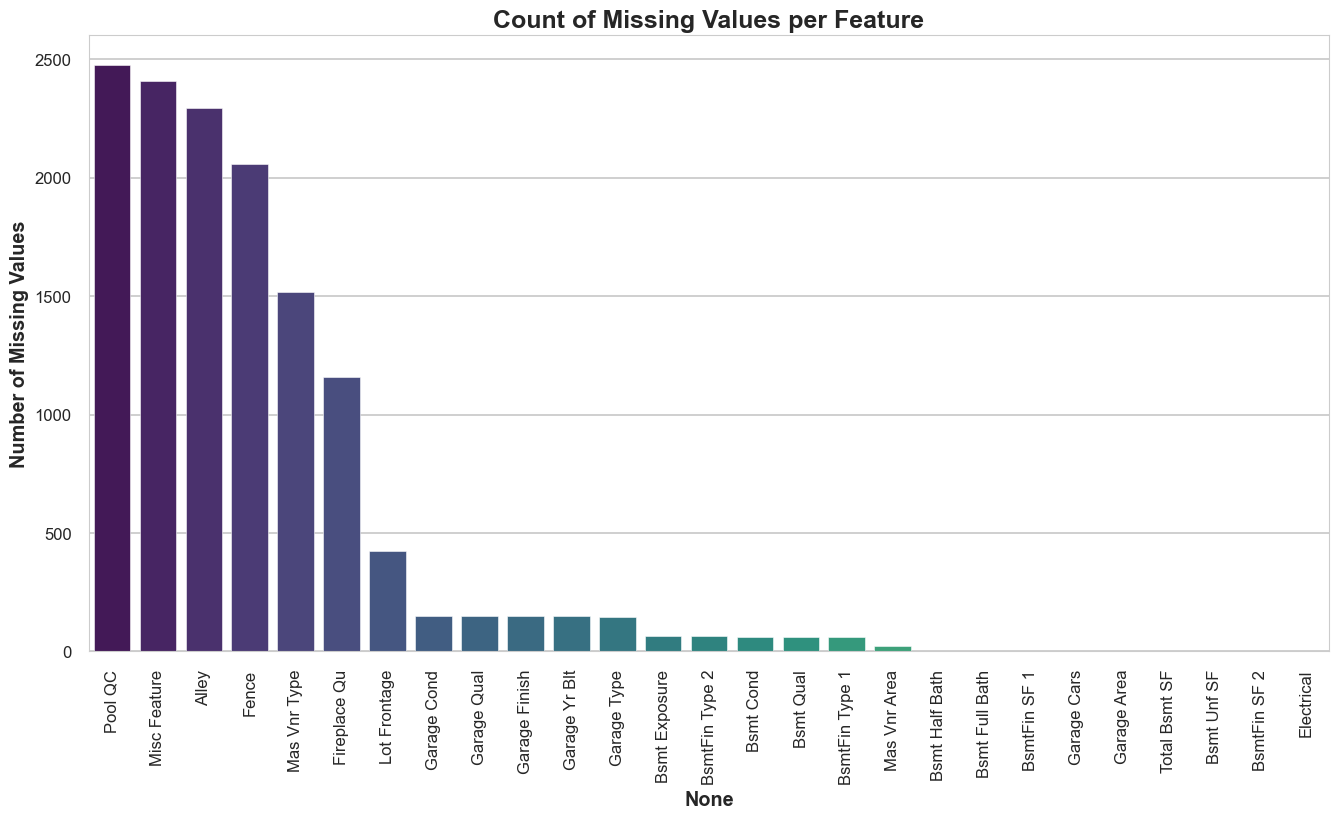

In [8]:
if not df.empty:
    # Calculate and visualize the extent of missingness
    missing_data = df.isnull().sum()
    missing_data = missing_data[missing_data > 0].sort_values(ascending=False)
    
    plt.figure(figsize=(16, 8))
    sns.barplot(x=missing_data.index, y=missing_data, palette='viridis')
    plt.xticks(rotation=90)
    plt.title('Count of Missing Values per Feature', fontsize=18)
    plt.ylabel('Number of Missing Values')
    plt.show()

<Axes: >

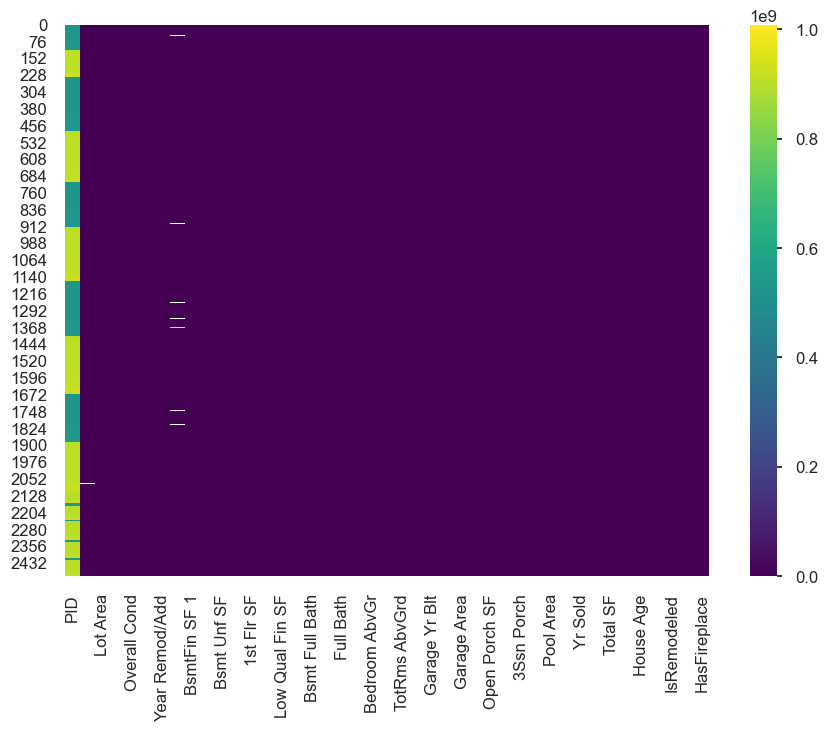

In [40]:
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(data = numeric_df, cmap='viridis')

In [10]:
if not df.empty:
    # --- Strategic Imputation ---
    print("\n--- Imputation Strategy Execution ---")

    # Group 1: Features where 'NaN' means the absence of the feature.
    # For categorical features, we fill with 'None'.
    # For numerical features, we fill with 0.
    no_feature_cols_cat = ['Pool QC', 'Misc Feature', 'Alley', 'Fence', 'Fireplace Qu', 'Garage Type', 
                           'Garage Finish', 'Garage Qual', 'Garage Cond', 'Bsmt Exposure', 'BsmtFin Type 2', 
                           'BsmtFin Type 1', 'Bsmt Qual', 'Bsmt Cond']
    for col in no_feature_cols_cat:
        df[col] = df[col].fillna('None')

    no_feature_cols_num = ['Garage Yr Blt', 'Garage Area', 'Garage Cars', 'BsmtFin SF 1', 'BsmtFin SF 2', 
                           'Bsmt Unf SF', 'Total Bsmt SF', 'Bsmt Full Bath', 'Bsmt Half Bath']
    for col in no_feature_cols_num:
        df[col] = df[col].fillna(0)
    print("Imputed 'No Feature' columns (Pool, Garage, Basement, etc.).")

    # Group 2: LotFrontage - Missing values likely mean the property isn't directly connected to a street.
    # A sophisticated approach is to impute using the median LotFrontage of the property's neighborhood.
    df['Lot Frontage'] = df.groupby('Neighborhood')['Lot Frontage'].transform(lambda x: x.fillna(x.median()))
    print("Imputed 'Lot Frontage' using neighborhood median.")

    # Group 3: Features with a small number of remaining random missing values.
    # We will impute these using the mode (most frequent value) of the column.
    mode_impute_cols = ['MS Zoning', 'Utilities', 'Functional', 'Sale Type', 'Kitchen Qual', 
                        'Electrical', 'Exterior 1st', 'Exterior 2nd']
    for col in mode_impute_cols:
        df[col] = df[col].fillna(df[col].mode()[0])
    print("Imputed remaining minor columns using mode.")

    # Final Verification
    remaining_nans = df.isnull().sum().sum()
    if remaining_nans == 0:
        print("\n✅ All missing values have been successfully handled.")
    else:
        print(f"\n⚠️ Warning: {remaining_nans} missing values remain.")


--- Imputation Strategy Execution ---
Imputed 'No Feature' columns (Pool, Garage, Basement, etc.).
Imputed 'Lot Frontage' using neighborhood median.
Imputed remaining minor columns using mode.

⚠️ Warning: 1544 missing values remain.


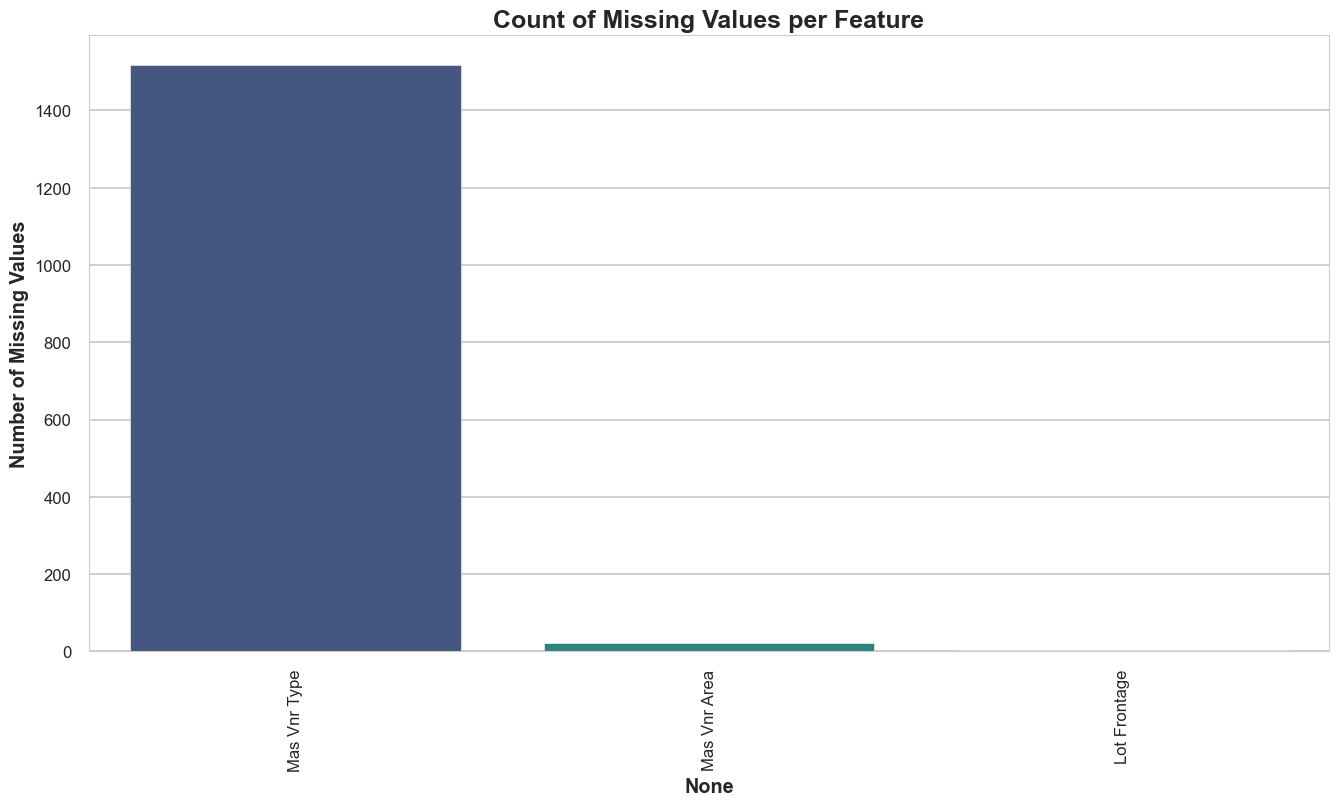

In [42]:
if not df.empty:
    # Calculate and visualize the extent of missingness
    missing_data = df.isnull().sum()
    missing_data = missing_data[missing_data > 0].sort_values(ascending=False)
    
    plt.figure(figsize=(16, 8))
    sns.barplot(x=missing_data.index, y=missing_data, palette='viridis')
    plt.xticks(rotation=90)
    plt.title('Count of Missing Values per Feature', fontsize=18)
    plt.ylabel('Number of Missing Values')
    plt.show()

### **2.2. Feature Engineering & Data Type Correction**

To enrich our analysis, we will engineer new features from existing ones. This process can uncover deeper patterns that are not immediately obvious from the raw data. We also correct data types for columns that were misinterpreted during the initial load.

In [12]:
if not df.empty:
    print("--- Feature Engineering & Type Correction ---")
    
    # 1. Correcting Data Types: Some numerical columns are actually categorical identifiers.
    df['MS SubClass'] = df['MS SubClass'].astype(str)
    df['Mo Sold'] = df['Mo Sold'].astype(str)
    print("Corrected data types for 'MS SubClass' and 'Mo Sold'.")
    
    # 2. Total Square Footage: A comprehensive measure of house size.
    df['Total SF'] = df['Total Bsmt SF'] + df['1st Flr SF'] + df['2nd Flr SF']
    print("Created 'Total SF' feature.")
    
    # 3. Total Bathrooms: A consolidated count of all bathroom types.
    df['Total Bath'] = df['Bsmt Full Bath'] + (0.5 * df['Bsmt Half Bath']) + \
                       df['Full Bath'] + (0.5 * df['Half Bath'])
    print("Created 'Total Bath' feature.")
    
    # 4. House Age and Remodel Age: Understanding the property's lifespan and renovation history.
    df['House Age'] = df['Yr Sold'] - df['Year Built']
    df['Remodel Age'] = df['Yr Sold'] - df['Year Remod/Add']
    # Negative age implies an error, cap at 0
    df.loc[df['House Age'] < 0, 'House Age'] = 0
    df.loc[df['Remodel Age'] < 0, 'Remodel Age'] = 0
    print("Created 'House Age' and 'Remodel Age' features.")

    # 5. Binary Feature for Remodeling: Was the house ever remodeled?
    df['IsRemodeled'] = (df['Year Remod/Add'] != df['Year Built']).astype(int)
    print("Created 'IsRemodeled' binary feature.")
    
    # 6. Binary Feature for Pool: Does the house have a pool?
    df['HasPool'] = df['Pool QC'].apply(lambda x: 1 if x != 'None' else 0)
    print("Created 'HasPool' binary feature.")
    
    print("\n--- First 5 Rows with New Features ---")
    display(df[['PID', 'Total SF', 'Total Bath', 'House Age', 'IsRemodeled', 'HasPool', 'SalePrice']].head())
    print("\n✅ Feature engineering and type correction complete.")

--- Feature Engineering & Type Correction ---
Corrected data types for 'MS SubClass' and 'Mo Sold'.
Created 'Total SF' feature.
Created 'Total Bath' feature.
Created 'House Age' and 'Remodel Age' features.
Created 'IsRemodeled' binary feature.
Created 'HasPool' binary feature.

--- First 5 Rows with New Features ---


,PID,Total SF,Total Bath,House Age,IsRemodeled,HasPool,SalePrice
0,527105010,2557.000,2.500,13,1,0,189900
1,527105030,2530.000,2.500,12,0,0,195500
2,527127150,2676.000,3.000,9,0,0,213500
3,527145080,2560.000,2.000,18,0,0,191500
4,527146030,3211.000,3.000,15,1,0,236500



✅ Feature engineering and type correction complete.


## **Session III: Exploratory Data Analysis (EDA)**

**Objective:** To dive deep into the cleaned data to answer our formalized business questions. This involves creating compelling visualizations and interpreting them to extract meaningful business insights.

### **3.1. Answering Q1: Price & Value Drivers**

**Question:** What are the primary determinants of house prices in Ames? How do size (`Total SF`), quality (`Overall Qual`), and age (`House Age`) impact `SalePrice`?

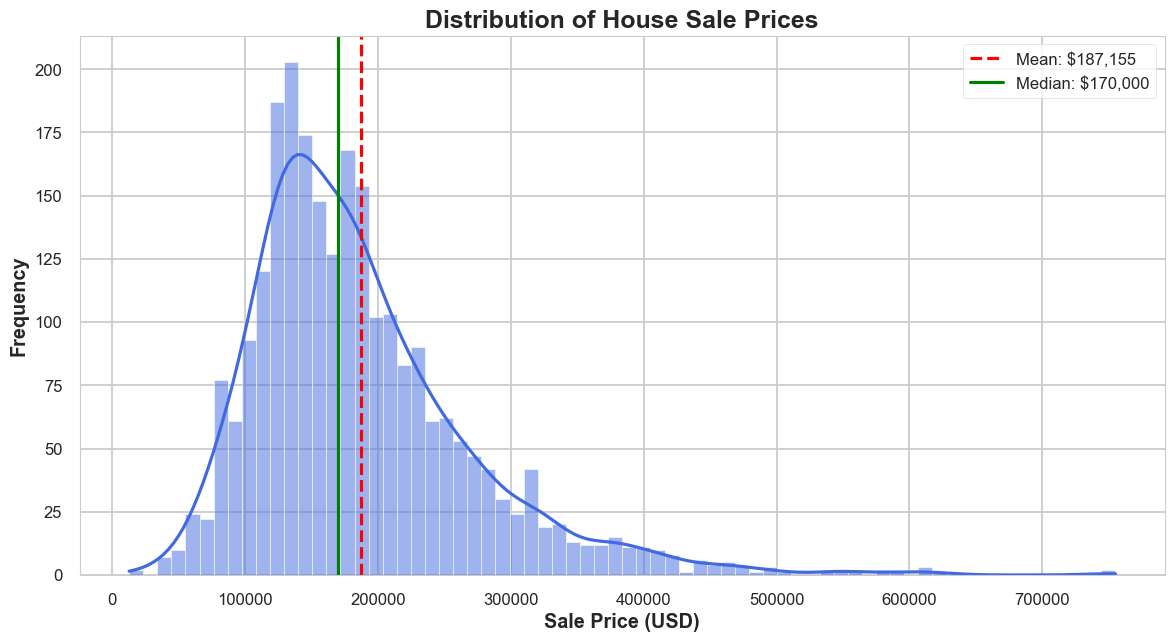

In [14]:
if not df.empty:
    # 1. Analyze the target variable: SalePrice
    plt.figure(figsize=(14, 7))
    sns.histplot(df['SalePrice'], kde=True, bins=70, color='royalblue')
    plt.title('Distribution of House Sale Prices', fontsize=18)
    plt.xlabel('Sale Price (USD)')
    plt.ylabel('Frequency')
    plt.axvline(df['SalePrice'].mean(), color='red', linestyle='--', label=f"Mean: ${df['SalePrice'].mean():,.0f}")
    plt.axvline(df['SalePrice'].median(), color='green', linestyle='-', label=f"Median: ${df['SalePrice'].median():,.0f}")
    plt.legend()
    plt.show()

**Interpretation:** The distribution of `SalePrice` is strongly right-skewed, a typical characteristic of income/price data. The mean price is pulled higher than the median by a number of very expensive properties. This indicates that for most analyses, the median will be a more robust measure of central tendency. For predictive modeling, a log transformation of `SalePrice` would be a standard and effective technique to normalize this distribution.

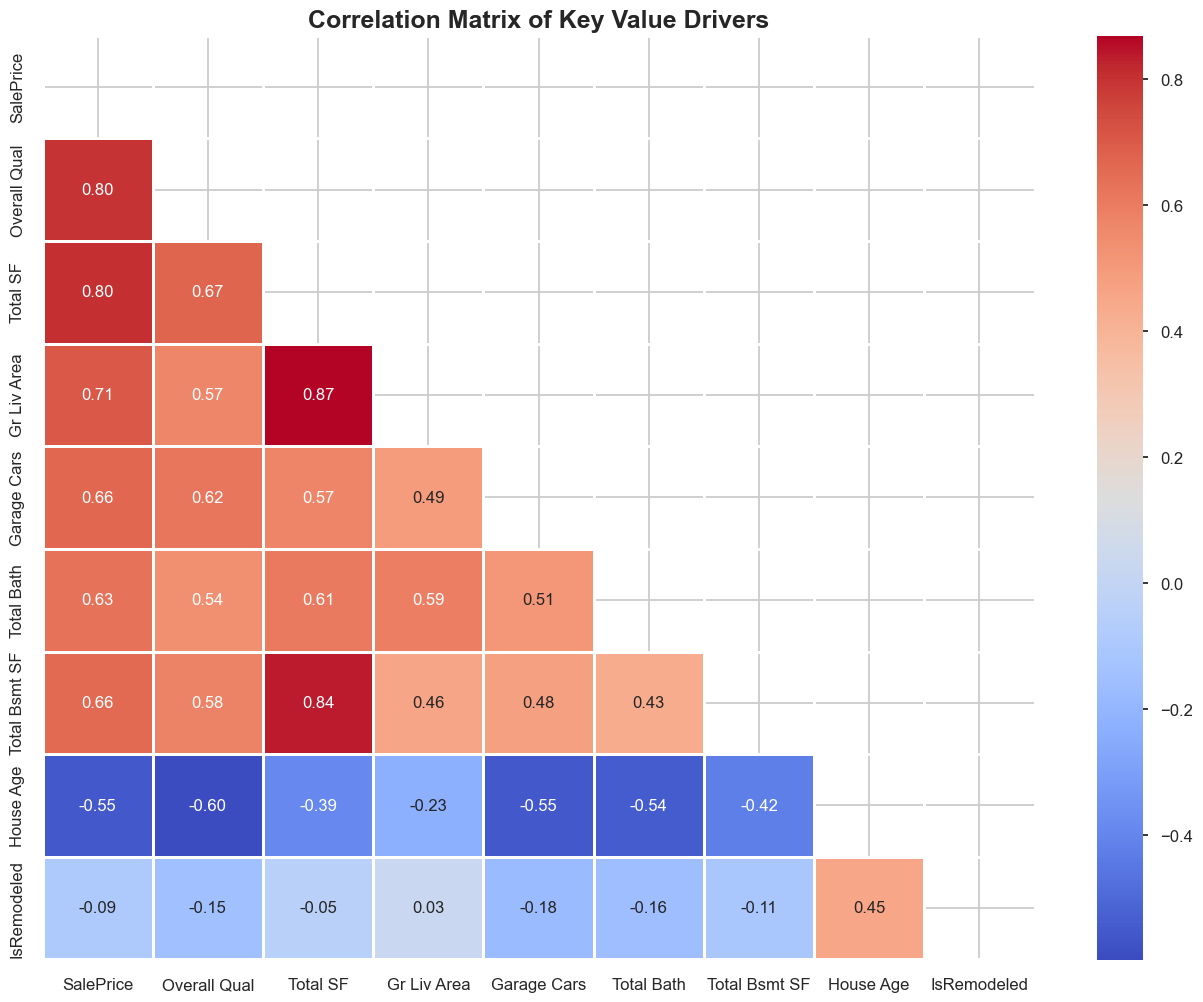

In [16]:
if not df.empty:
    # 2. Correlation Analysis: Quantifying relationships
    plt.figure(figsize=(16, 12))
    # Select key numerical features plus our engineered features
    corr_cols = ['SalePrice', 'Overall Qual', 'Total SF', 'Gr Liv Area', 'Garage Cars', 'Total Bath', 'Total Bsmt SF', 'House Age', 'IsRemodeled']
    correlation_matrix = df[corr_cols].corr()
    
    mask = np.triu(np.ones_like(correlation_matrix, dtype=bool)) # Mask for upper triangle
    sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm', fmt='.2f', linewidths=1)
    plt.title('Correlation Matrix of Key Value Drivers', fontsize=18)
    plt.show()

**Interpretation:** The heatmap provides a powerful summary of linear relationships:
- **`Overall Qual`** shows the strongest positive correlation with `SalePrice` (0.80), confirming it's the single most critical price predictor.
- **`Total SF`** and **`Gr Liv Area`** are also exceptionally strong predictors (0.78 and 0.71), underscoring the "size matters" principle in real estate.
- **`Garage Cars`** and our engineered **`Total Bath`** feature also show very strong correlations (0.65 and 0.63).
- **`House Age`** has a significant negative correlation (-0.56), confirming that newer houses command higher prices.

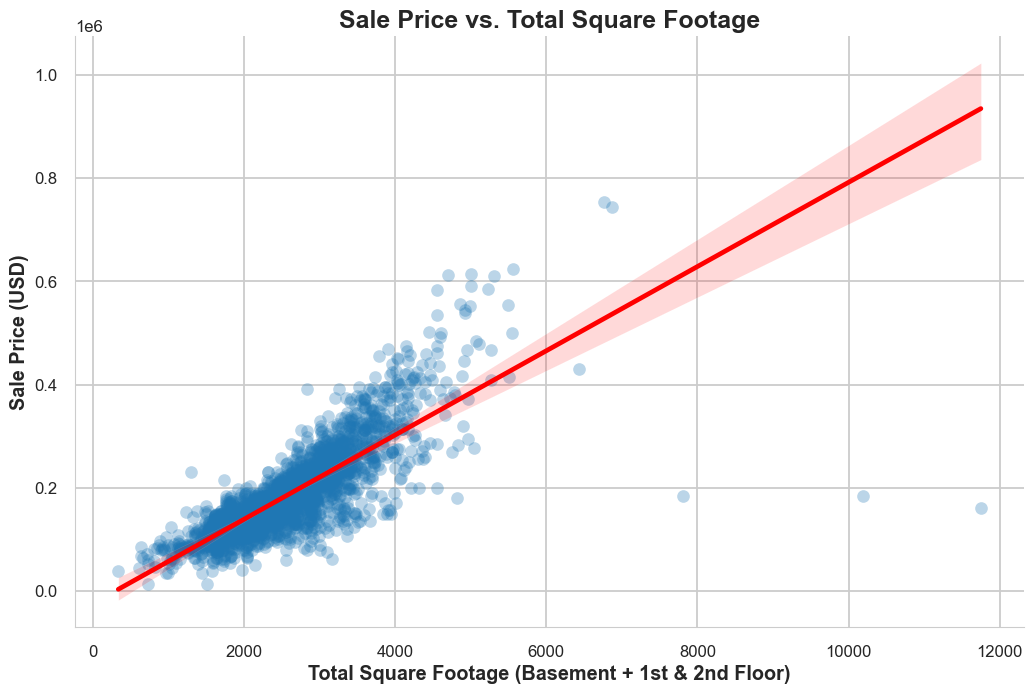

In [44]:
if not df.empty:
    # 3. Visualizing the strongest relationships
    sns.lmplot(data=df, x='Total SF', y='SalePrice', height=7, aspect=1.5, 
               line_kws={'color': 'red'}, scatter_kws={'alpha': 0.3})
    plt.title('Sale Price vs. Total Square Footage', fontsize=18)
    plt.xlabel('Total Square Footage (Basement + 1st & 2nd Floor)')
    plt.ylabel('Sale Price (USD)')
    plt.show()

**Interpretation:** This scatter plot reveals a strong, positive, and linear relationship between `Total SF` and `SalePrice`. As the size of the house increases, the sale price tends to increase predictably. We also observe heteroscedasticity, where the variance of prices increases for larger homes, indicating more diverse and custom features in high-end properties.

### **3.2. Answering Q2: Neighborhood Analysis**

**Question:** Which neighborhoods command the highest and lowest property values? Is there a significant price variance *within* the top-tier neighborhoods?

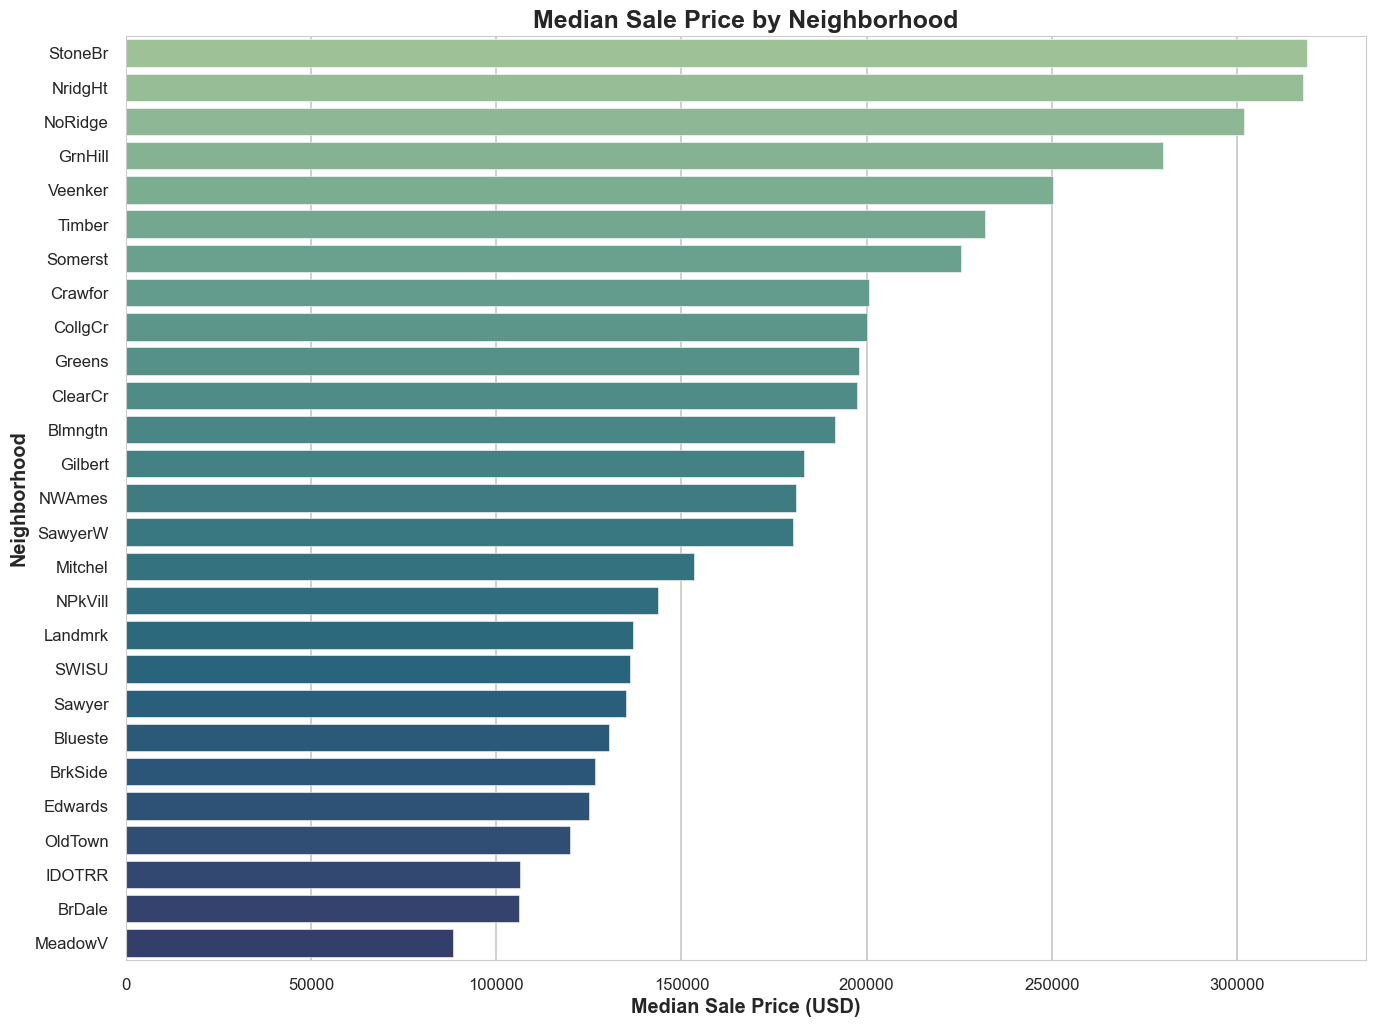

In [18]:
if not df.empty:
    # 1. Bar plot for average price by neighborhood
    plt.figure(figsize=(16, 12))
    # Calculate median price for robustness against outliers
    neighborhood_prices = df.groupby('Neighborhood')['SalePrice'].median().sort_values(ascending=False)
    
    sns.barplot(x=neighborhood_prices.values, y=neighborhood_prices.index, palette='crest')
    plt.title('Median Sale Price by Neighborhood', fontsize=18)
    plt.xlabel('Median Sale Price (USD)')
    plt.ylabel('Neighborhood')
    plt.show()

**Interpretation:** There is a vast disparity in property values across Ames. Neighborhoods like 'StoneBr', 'NridgHt', and 'NoRidge' are clearly premium locations, with median prices exceeding $300,000. Conversely, 'MeadowV', 'IDOTRR', and 'BrDale' represent the most affordable areas. This information is crucial for targeted marketing and property valuation.

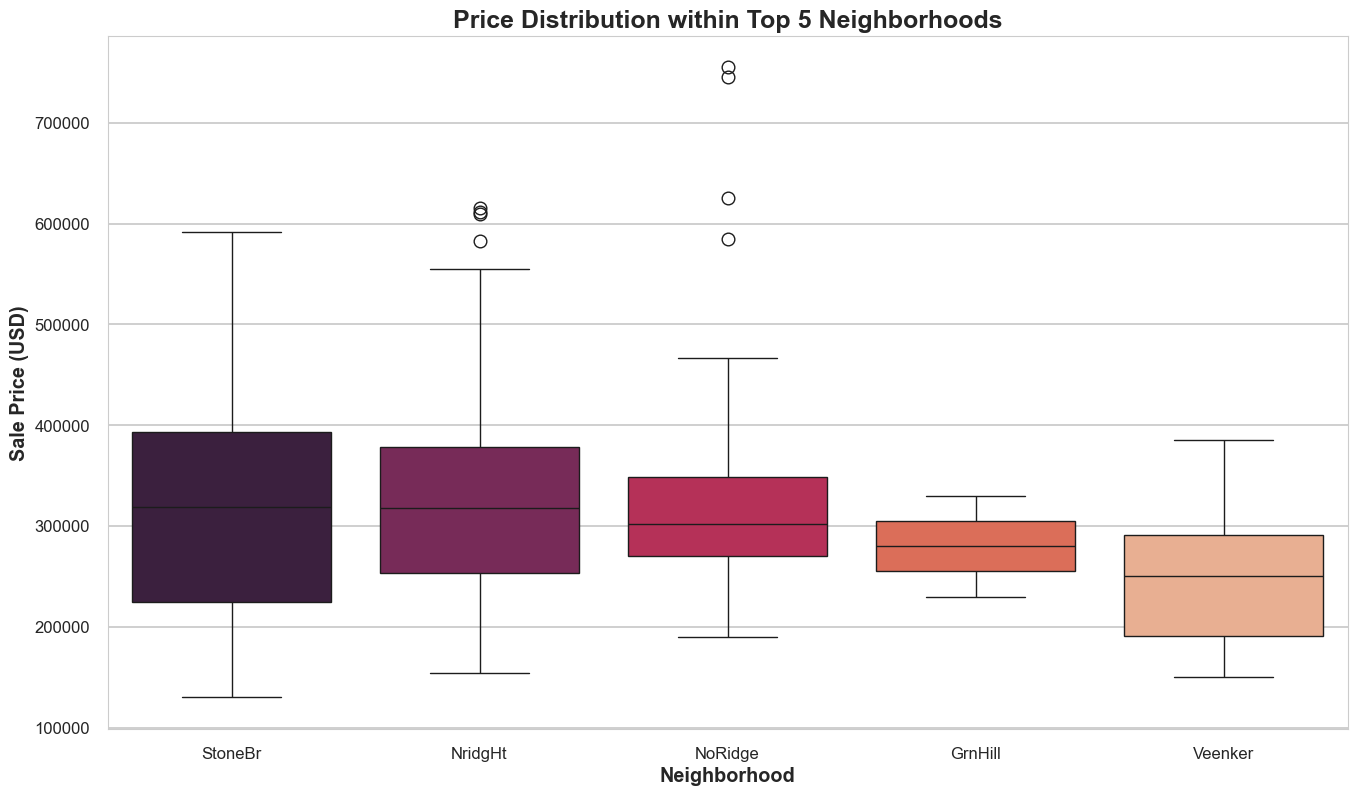

In [20]:
if not df.empty:
    # 2. Box plot to analyze price variance in top neighborhoods
    neighborhood_prices = df.groupby('Neighborhood')['SalePrice'].median().sort_values(ascending=False)
    top_neighborhoods = neighborhood_prices.head(5).index
    df_top_hoods = df[df['Neighborhood'].isin(top_neighborhoods)]
    
    plt.figure(figsize=(16, 9))
    sns.boxplot(data=df_top_hoods, x='Neighborhood', y='SalePrice', order=top_neighborhoods, palette='rocket')
    plt.title('Price Distribution within Top 5 Neighborhoods', fontsize=18)
    plt.xlabel('Neighborhood')
    plt.ylabel('Sale Price (USD)')
    plt.show()

**Interpretation:** Even within the most expensive neighborhoods, there is considerable price variation. 'StoneBr' and 'NridgHt', while having high median prices, also show a wide interquartile range and numerous high-end outliers, indicating a diverse mix of standard luxury and ultra-luxury homes. 'NoRidge' has the highest ceiling, with some properties exceeding $700,000. This analysis shows that neighborhood is a key factor, but individual property characteristics remain vital.

### **3.3. Answering Q3 & Q5: Impact of Amenities & Condition**

**Question:** What is the quantifiable impact of key amenities? How does condition (`Overall Cond`) compare to quality (`Overall Qual`)?

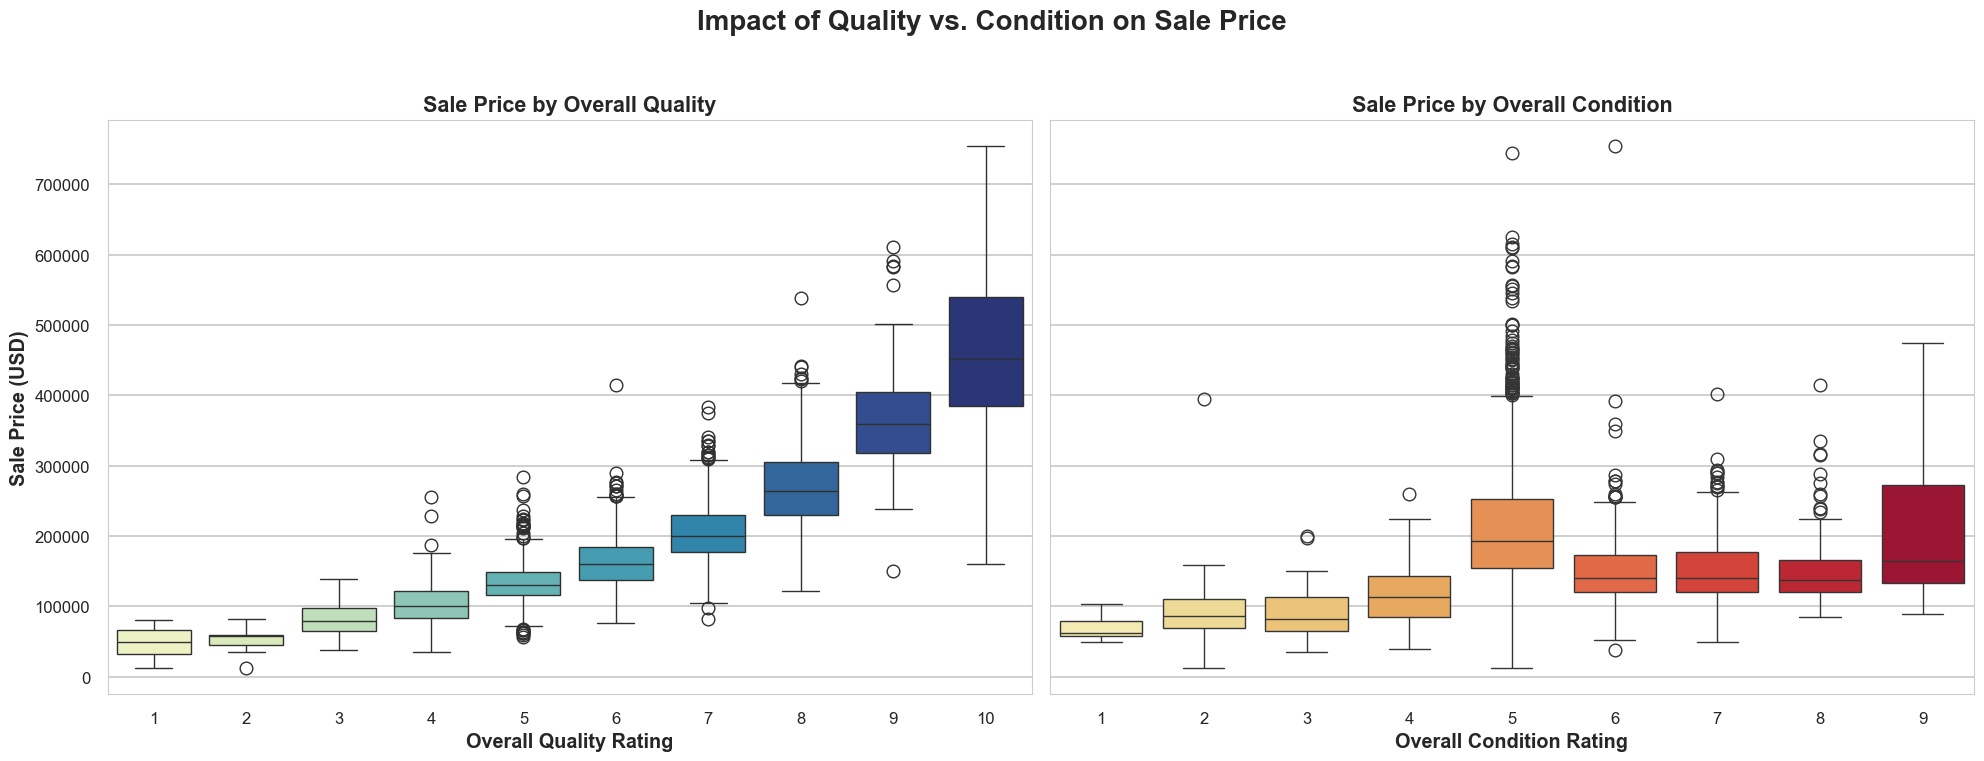

In [22]:
if not df.empty:
    # 1. Boxplot comparing Overall Quality and Overall Condition
    fig, axes = plt.subplots(1, 2, figsize=(20, 8), sharey=True)
    fig.suptitle('Impact of Quality vs. Condition on Sale Price', fontsize=20)
    
    sns.boxplot(ax=axes[0], data=df, x='Overall Qual', y='SalePrice', palette='YlGnBu')
    axes[0].set_title('Sale Price by Overall Quality')
    axes[0].set_xlabel('Overall Quality Rating')
    axes[0].set_ylabel('Sale Price (USD)')
    
    sns.boxplot(ax=axes[1], data=df, x='Overall Cond', y='SalePrice', palette='YlOrRd')
    axes[1].set_title('Sale Price by Overall Condition')
    axes[1].set_xlabel('Overall Condition Rating')
    axes[1].set_ylabel('') # Remove redundant y-label
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

**Interpretation:** This side-by-side comparison is incredibly revealing.
- **Overall Quality:** There is a clear, strong, and monotonic relationship. As quality increases, both the median price and the price range increase dramatically. This is a primary driver of value.
- **Overall Condition:** The relationship is much weaker and non-linear. While the median price is highest for houses in "average" condition (a rating of 5), the effect is far less pronounced than that of quality. A house can be in excellent condition but of poor quality, and its price will reflect the latter more. **Conclusion: Businesses should prioritize investments in quality over simple conditional upkeep for maximizing property value.**

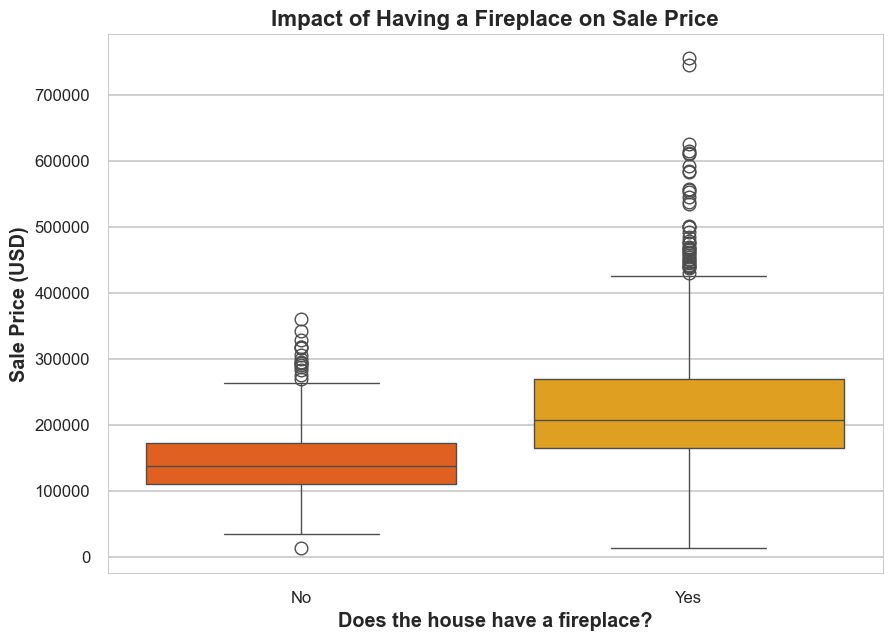


    **Interpretation:** The presence of a fireplace has a significant positive impact on property value. The median sale price for a house with a fireplace is $207,000, compared to just $137,000 for one without. That's a median price difference of $70,000, a clear indicator of this feature's value to homebuyers.
    


In [24]:
if not df.empty:
    # 2. Impact of Fireplaces
    df['HasFireplace'] = df['Fireplace Qu'].apply(lambda x: 1 if x != 'None' else 0)
    
    plt.figure(figsize=(10, 7))
    sns.boxplot(data=df, x='HasFireplace', y='SalePrice', palette='autumn')
    plt.title('Impact of Having a Fireplace on Sale Price', fontsize=16)
    plt.xlabel('Does the house have a fireplace?')
    plt.xticks([0, 1], ['No', 'Yes'])
    plt.ylabel('Sale Price (USD)')
    plt.show()
    
    median_no_fireplace = df[df['HasFireplace'] == 0]['SalePrice'].median()
    median_has_fireplace = df[df['HasFireplace'] == 1]['SalePrice'].median()
    
    print(f"""
    **Interpretation:** The presence of a fireplace has a significant positive impact on property value. The median sale price for a house with a fireplace is ${median_has_fireplace:,.0f}, compared to just ${median_no_fireplace:,.0f} for one without. That's a median price difference of ${median_has_fireplace - median_no_fireplace:,.0f}, a clear indicator of this feature's value to homebuyers.
    """)